# SHAP Analysis

In [1]:
# Import libraries
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import random

import pyarrow as pa
import pyarrow.parquet as pq
import sklearn
import shap
import matplotlib.pyplot as plt

In [9]:
future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'
model_dir = future_dir + "/Models"

# Load Data

dataset1 = 'Dataset_RF_Model_SW_COMIDS.csv'
#dataset1 = 'Dataset_RF_Model_GW_COMIDS.csv'

modelpath = "/torch_models_5fold_future_NO3_sw.pth"
#modelpath = "/torch_models_kfold_future_NO3_gw.pth"

testnames = "/test_datasets_sw.pkl"
#testnames = "/test_datasets_gw.pkl"

In [ ]:
# Load Observation Dataset


input_data_ = pd.read_csv(future_dir+dataset1)
input_data = input_data_.drop(columns=['COMID','viol_freq']) 
#y = input_data['Viol_Class'].values
#ncols = input_data.shape[1]
#ncols

In [ ]:
# ## Save Preditor Data for SHAP Analysis
# X_input_data = input_data.drop(columns=['Viol_Class']).values
# X_input_data.shape

# #  Convert to tensor data
# X_input_data = torch.from_numpy(X_input_data).type(torch.float)
# X_input_data.shape,X_input_data.dtype

# # Find the size of the smallest class
# min_size = input_data['Viol_Class'].value_counts().min()

# min_size  = min_size * 10

# # Sample exactly 'min_size' elements from each binary group
# #balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42).reset_index(drop=True)

# # If increasing the min_size, you can use the 'replace=True' argument to allow for sampling with replacement
# balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42, replace=True).reset_index(drop=True)


# # Convert to tensors and split into train and test sets
# from sklearn.model_selection import train_test_split
# #X = input_data.drop(columns=['Viol_Class']).values # when use this the model just predicts the majority class
# #y = input_data['Viol_Class'].values
# X = balanced_df.drop(columns=['Viol_Class']).values
# y = balanced_df['Viol_Class'].values

# # Turn data into tensors
# X = torch.from_numpy(X).type(torch.float)
# y = torch.from_numpy(y).type(torch.float)

# # Make a copy to use later
# X_full = X.clone()
# y_full = y.clone()

# # Split into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, 
#                                                     y, 
#                                                     test_size=0.2,
#                                                     random_state=2
# )

# nrows = X_train.size()[0]
# ncols = X_train.size()[1]

C:\Users\MPennino\AppData\Local\Temp\ipykernel_6428\3652074261.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at D:\bld\libtorch_1784990676194\work\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


In [5]:
from torch.utils.data import DataLoader, TensorDataset, SubsetRandomSampler

X_input_data = input_data.drop(columns=['Viol_Class']).values
X_input_data.shape

#  Convert to tensor data
X_input_data = torch.from_numpy(X_input_data).type(torch.float)
X_input_data.shape,X_input_data.dtype

# Find the size of the smallest class
min_size = input_data['Viol_Class'].value_counts().min()

min_size  = min_size * 10

# Sample exactly 'min_size' elements from each binary group
#balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42).reset_index(drop=True)

# If increasing the min_size, you can use the 'replace=True' argument to allow for sampling with replacement
balanced_df = input_data.groupby('Viol_Class').sample(n=min_size, random_state=42, replace=True).reset_index(drop=True)


# Convert to tensors and split into train and test sets
from sklearn.model_selection import train_test_split
#X = input_data.drop(columns=['Viol_Class']).values # when use this the model just predicts the majority class
#y = input_data['Viol_Class'].values
X = balanced_df.drop(columns=['Viol_Class']).values
y = balanced_df['Viol_Class'].values

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Make a copy to use later
X_full = X.clone()
y_full = y.clone()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=2
)

nrows = X_train.size()[0]
ncols = X_train.size()[1]
X_tensor = X.clone().detach()
y_tensor = y.clone().detach().unsqueeze(1) # Shape: [1000, 1] for BCELoss
dataset = TensorDataset(X_tensor, y_tensor)
len(dataset)

820

In [6]:
batchsize = int(len(dataset) * 0.2)
batchsize

164

In [7]:
import torch
import torch.nn as nn

class ImprovedBinaryClassifier(nn.Module):
    def __init__(self, input_dim=ncols, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.1),             # Prevents dead neurons
            nn.BatchNorm1d(hidden_dim),     # Stabilizes training
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),                # Prevents overfitting
            
            nn.Linear(hidden_dim, 1)        # Outputs raw logits (No Sigmoid here!)
        )
        
    def forward(self, x):
        return self.network(x)

In [ ]:
# Model for kfold models
checkpoint = torch.load(model_dir + modelpath, weights_only=False)
len(checkpoint)

loaded_models = [ImprovedBinaryClassifier() for _ in range(len(checkpoint))]  # List comprehension for brevity

models = []
# 3. Restore the weights for each individual model
for i, model in enumerate(loaded_models):
    model.load_state_dict(checkpoint[f"model_{i}"])

    models.append(model)

    # 4. ALWAYS switch to evaluation mode if you are ready to test/predict!
    #model.eval()
    #print(i)
len(models), type(models[0])

(10, __main__.ImprovedBinaryClassifier)

In [ ]:
# # Load the Model (for single model)
# future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'
# model_dir = future_dir + "/Models"
# model_dir

# filename = '/torch_model_future_NO3_sw.pth'

# loaded_model = torch.load(model_dir + filename, weights_only=False)
# loaded_model.eval()

ImprovedBinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [11]:
# Need to pull out one of the models for the SHAP analysis - later could run SHAP for each 
loaded_model = models[3]
loaded_model.eval()

ImprovedBinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [12]:
# Create Explainer object that can calculate shap values
#explainer = shap.TreeExplainer(random_forest)
#explainer = shap.DeepExplainer(model1,X_train)
#explainer = shap.PartitionExplainer(model1,X_train)
explainer = shap.GradientExplainer(loaded_model,X_train)

In [13]:
#pred_data.head(3)
X_full.shape, X_input_data.shape, X_full.dtype, X_input_data.dtype, len(X_input_data)

(torch.Size([820, 13]),
 torch.Size([14934, 13]),
 torch.float32,
 torch.float32,
 14934)

In [ ]:
# Calculate Shap values
#choosen_instance = X_test.loc[[50]]
#shap_values = explainer.shap_values(choosen_instance)
#shap_values = explainer(X_test) # 8 sec # this a tensor object without field names
#shap_values = explainer(X_full) # 40 sec # this a tensor object without field names
shap_values = explainer(X_input_data) # 6-8 min for 15,000 rows,11 min 4.3 sec (32,000 rows GW), 3 min for 8,700 rows # this a tensor object without field names
# ~8 min for 15,000 rows

#shap_values = explainer(pred_data) # 20 sec # this a dataframe object with field names, but doesnt work

#shap_values = explainer.shap_values(pred_data)

In [15]:
# Add in feature names to shap_values object
names = input_data.columns.tolist()
names = names[:-1] 
shap_values1 = shap_values
shap_values1.feature_names = names

In [16]:
# Creates a DataFrame of SHAP values
df_shap = pd.DataFrame(
    data=shap_values1[:,:, 0].values, 
    columns=shap_values1[:, :, 0].feature_names
)
#df_shap.head(5)
df_shap.shape, type(shap_values)

((14934, 13), shap._explanation.Explanation)

C:\Users\MPennino\AppData\Local\Temp\ipykernel_6428\784512701.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset


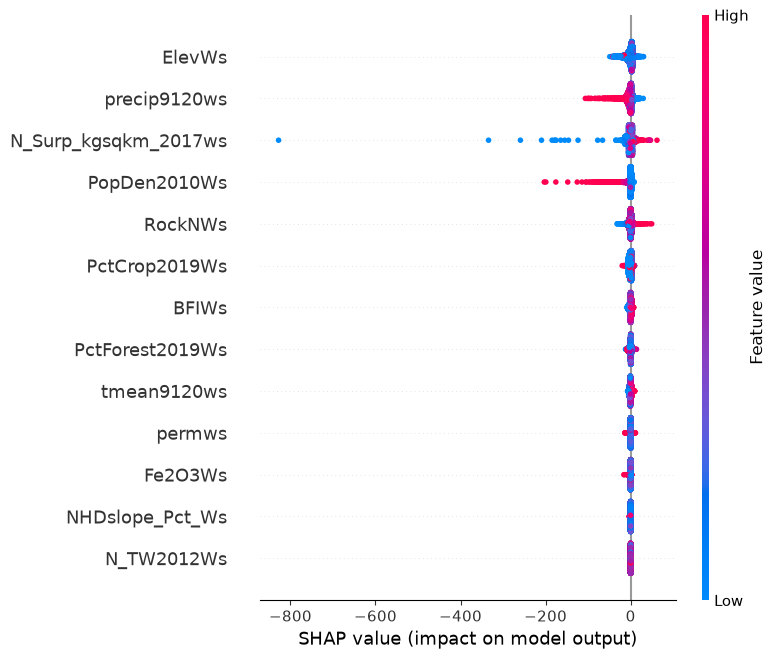

In [17]:
# Visualize
#shap.summary_plot(shap_values[0], X_test.numpy())
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy()) # works but no feature names
#shap.summary_plot(shap_values1[:,:, 0].values, X_test.numpy(),feature_names=names) # works if generate shape values based on test dataset
#shap.summary_plot(shap_values1[:,:, 0].values, X_full.numpy(),feature_names=names) # works if generate shape values based on test dataset

# This one use to work
shap.summary_plot(shap_values1[:,:, 0].values, X_input_data.numpy(),feature_names=names) # works if generate shape values based on test dataset

#shap.summary_plot(shap_values1[:,:, 0].values, input_data[0:393:].drop(columns=['Viol_Class'])) 

# SHAP Scatter Plots

Text(0, 0.5, 'SHAP Value')

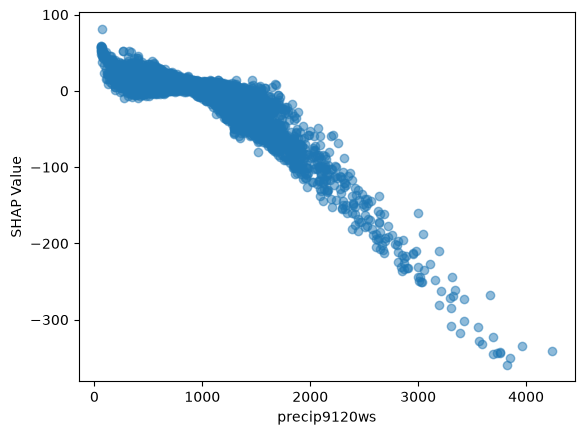

In [12]:
# Test out plotting SHAP values against input data by chaning the index of the input data and shap values
indexN = 3
plt.scatter(X_input_data[:, indexN], shap_values1[:,:, 0][:, indexN].values, alpha=0.5)
plt.xlabel(names[indexN])
plt.ylabel('SHAP Value')

In [ ]:
## Function to plot shap vs. input values
# This plots all figures separately.
# def plot_shap_vs_input(shap_values, input_values, feature_names):
#     for i, feature in enumerate(feature_names):
#         plt.scatter(input_values[:, i], shap_values[:, i], alpha=0.5)
#         plt.xlabel(feature)
#         plt.ylabel('SHAP Value')
#         plt.title(f'SHAP Values for {feature}')
#         plt.show()

In [13]:
def plot_shap_vs_input2(shap_values, input_values, feature_names):

    fig, axes = plt.subplots(3, 4,figsize=(12, 8))

    # Flattening the axes array makes it easier to loop through
    for i, ax in enumerate(axes.flat, start=1):
        ax.scatter(input_values[:, i-1], shap_values[:, i-1])
        
        # Use set_xlabel and set_ylabel for individual subplot axes
        ax.set_xlabel(f"{feature_names[i-1]}")
        ax.set_ylabel("SHAP Value")

    plt.tight_layout()
    plt.show()

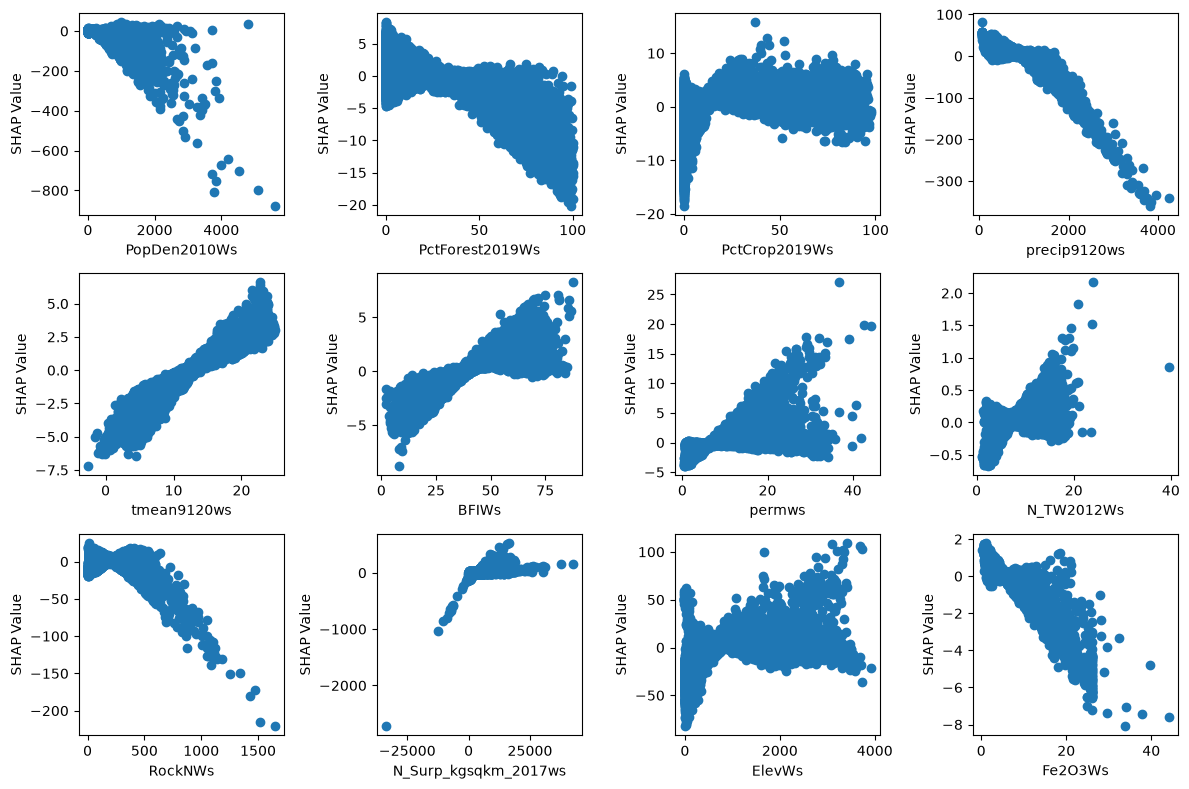

In [14]:
plot_shap_vs_input2(shap_values1[:,:, 0].values, X_input_data.numpy(), names)

# SHAP MAPS

In [16]:
# Read in HUC12 centroids (1m 4.2s)
import geopandas as gpd
huc12_centroids_path = 'D:/ArcGIS/Boundaries/HUC12_catchments/HUC12_centroids.shp'
huc12_p = gpd.read_file(huc12_centroids_path)

ImportError: cannot import name 'cascaded_union' from 'shapely.ops' (c:\Users\MPennino\anaconda3\envs\future_env\Lib\site-packages\shapely\ops.py)

In [ ]:
# Merge Prediction results with Shapefile
#type(cats_s), cats_s.columns
preds_s = huc12_p.merge(preds, on="COMID", how="left")
preds_s.shape, preds_s.columns, type(preds_s)

# SAVE SHAP RESULTS

In [ ]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
# Save SHAP Results
filename1 = 'torch_SHAP_Values_DF_COMID_All_Observed_sw.parquet'
#filename = 'torch_SHAP_Values_HUC12_All_Observed_gw.parquet'

filename2 = 'torch_SHAP_Values_COMID_All_Observed_sw.parquet'


table1 = pa.Table.from_pandas(df_shap)
table2 = pa.Table.from_pandas(shap_values1)

pq.write_table(table, future_dir + filename1)
pq.write_table(shap_values1, future_dir + filename2)
